# PVGIS-only ST-GNN — Monaco neural-SDE (drift/diffusion) pipeline

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `RUN_SWEEP`, `CREATE_SWEEP`, `LOG_TO_WANDB`.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [2]:
PVGIS_DIR = pipe.PVGIS_DIR
TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
OK       train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [3]:
if not (Path(TEST_ANOMALY_SCORES).exists() and Path(TRAIN_ANOMALY_SCORES).exists()):
    base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2023'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
    print('# Test year 2019:')
    print(base + ' --years 2019')
    print()
    print('# Train years 2016-2018 (aggregated):')
    print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

anomaly scores present.


## 2. Single-run config

In [4]:
# === EXPERIMENT SELECTOR ===
# beta_nll   = Kong-faithful (train on ALL cells) + beta-NLL (Seitzer 2022,
#              beta_nll=0.5 from DEFAULT_CONFIG) to stop the variance runaway
#              that under-fits the mean. This is the current main run.
# kong_all   = plain Kong NLL on all cells (no beta-NLL) — the under-fit baseline.
# normal_only= label-defined ablation: optimise only on normal target/history
#              cells (NOT Kong: it holds rare out of the loss).
# student_t* = beta_nll + Student-t likelihood (heavier tails -> better tail
#              coverage at 95/99%). nll_dist=student_t, student_t_nu sweeps the
#              degrees of freedom (smaller = heavier tails; nu->inf == Gaussian).
EXPERIMENT = 'student_t'   # 'beta_nll' | 'kong_all' | 'baseline' | 'exp1' | 'exp2' | 'normal_only' | 'student_t' | 'student_t_nu3' | 'student_t_nu10'

_OVERRIDES = {
    'baseline': {},
    'exp1': {'epochs': 20, 'name': 'ep20'},
    'exp2': {'epochs': 20, 'n_sde_steps': 8, 'sigma_max': 2.0, 'name': 'sde8_sm2p0_ep20'},
    # Kong-faithful + beta-NLL (beta_nll=0.5 inherited from DEFAULT_CONFIG).
    'beta_nll': {'epochs': 10, 'train_normal_only': False, 'name': 'beta_nll_ep10'},
    # Plain Kong NLL, all data (beta_nll=0 to disable beta-NLL).
    'kong_all': {'epochs': 10, 'train_normal_only': False, 'beta_nll': 0.0, 'name': 'kong_all_ep10'},
    # Requires TRAIN-year anomaly scores to select normal target/history cells.
    'normal_only': {'epochs': 10, 'train_normal_only': True, 'name': 'normal_only_ep10'},
    # beta-NLL + Student-t likelihood (heavy tails). PI uses the t-quantile.
    'student_t': {'epochs': 10, 'train_normal_only': False,
                  'nll_dist': 'student_t', 'student_t_nu': 5.0,
                  'name': 'student_t_nu5_ep10'},
    'student_t_nu3': {'epochs': 10, 'train_normal_only': False,
                      'nll_dist': 'student_t', 'student_t_nu': 3.0,
                      'name': 'student_t_nu3_ep10'},
    'student_t_nu10': {'epochs': 10, 'train_normal_only': False,
                       'nll_dist': 'student_t', 'student_t_nu': 10.0,
                       'name': 'student_t_nu10_ep10'},
}

BASE_CONFIG = {**pipe.DEFAULT_CONFIG, **_OVERRIDES[EXPERIMENT]}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('WARNING: out_dir already exists — a run would overwrite its files.')

experiment: student_t
config    : {'train_years': '2016,2017,2018', 'test_year': 2019, 'seq_len': 24, 'horizon': 1, 'target_variable': 'pv_power_output', 'model_type': 'stgnn', 'feature_set': 'full', 'epochs': 10, 'batch_size': 16, 'lr': 0.001, 'lr_g': 0.01, 'beta_nll': 0.5, 'nll_dist': 'student_t', 'student_t_nu': 5.0, 'dropout': 0.3, 'mc_samples': 10, 'seed': 1, 'n_sde_steps': 4, 'sigma_max': 0.5, 'sde_sigma_initial': 0.1, 'sde_sigma_warmup_epochs': 2, 'ood_noise_std': 2.0, 'irradiance_loss_weight': 0.1, 'pv_target_clip_max': 'none', 'train_normal_only': False, 'name': 'student_t_nu5_ep10'}
out_dir   : outputs/pvgis_stgnn_student_t_nu5_ep10_seed1
run_name  : pvgis_stgnn_student_t_nu5_ep10_seed1


## 3. Training command

In [ ]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
print(' \\\n  '.join(train_cmd))

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [ ]:
RUN_TRAINING = True

if RUN_TRAINING:
    subprocess.run(train_cmd, check=True)
else:
    print('RUN_TRAINING is False — not launching. Command above is what would run.')

## 5. Post-hoc analysis

In [ ]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(histograms + boxplots). Monaco SDE U-Net: one total uncertainty band
(SDE-sample spread), no aleatoric/epistemic split.

In [5]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (12, 26)
OK  metrics_by_anomaly_label.csv  (6, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (6, 8)
OK  daytime_bin_anomaly_metrics.csv  (36, 9)
OK  uncertainty_response.csv  (5, 8)
OK  sharpness_overview.csv  (7, 10)


In [6]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.941306,42.966109,70.673134,48.458684,249.134024,0.279342
1,normal,4195053,0.941604,42.012040,68.919565,48.465763,249.170421,0.279383
2,rare_extreme,552492,0.939040,50.210316,82.784896,48.404929,248.857661,0.279032
3,unusually_low_solar_potential,99535,0.938253,87.923821,123.224757,59.058612,303.629992,0.340446
4,unusually_high_solar_potential,38401,0.967084,41.241973,71.081042,49.954971,256.826683,0.287967
5,extreme_temperature_condition,238447,0.947464,36.157194,62.157553,42.096144,216.423164,0.242665
6,extreme_wind_condition,221945,0.931965,51.529540,81.821566,52.706667,270.973600,0.303830


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil
0,daytime_0_20,396207,18.851605,32.784727,0.899136,16.921199,86.994654,0.097543
1,daytime_20_40,376626,35.670129,57.444516,0.900564,30.561102,157.119626,0.176171
2,daytime_40_60,352255,46.471005,76.543448,0.913245,40.371678,207.557406,0.232724
3,daytime_60_80,266151,53.434889,85.615860,0.921999,47.667954,245.068754,0.274784
4,daytime_80_100,206451,53.055609,83.999812,0.923992,51.621005,265.392033,0.297571
5,daytime_gt_100,3149855,44.933916,72.534974,0.957386,55.329585,284.458454,0.318950


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag
0,rare_extreme,1.195141,1.201181,0.998745,-0.002564,0.998745,0.998745,True
1,unusually_low_solar_potential,2.092824,1.787950,1.218564,-0.003351,1.218564,1.218564,True
2,unusually_high_solar_potential,0.981670,1.031362,1.030727,0.025480,1.030727,1.030727,False
3,extreme_temperature_condition,0.860639,0.901885,0.868575,0.005860,0.868575,0.868575,False
4,extreme_wind_condition,1.226542,1.187204,1.087503,-0.009639,1.087503,1.087503,True


In [7]:
# SDE band (total predictive std) by anomaly group. Monaco does not split
# aleatoric/epistemic: the band is the spread of the SDE samples. Seasonal
# anomaly labels are evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,48.465763
rare_or_extreme,48.404929


In [8]:
import pandas as pd
# Epistemic vs aleatoric on the CURRENTLY SELECTED experiment (run cell 2 first).
# Does NOT reassign out_dir and uses a private _ea frame so it can't shadow the
# reliability cell's `df` guard.
_ea = pd.read_csv(str(Path(out_dir) / 'predictions.csv'),
                  usecols=['epistemic_std', 'aleatoric_std', 'solar_irradiance_poa_target'])
_ea_day = _ea[_ea['solar_irradiance_poa_target'] > 10]
print('out_dir:', out_dir)
print(_ea_day[['epistemic_std', 'aleatoric_std']].mean())
print('epistemic / aleatoric ratio:',
      (_ea_day['epistemic_std'].mean() / _ea_day['aleatoric_std'].mean()).round(4))

out_dir: outputs/pvgis_stgnn_student_t_nu5_ep10_seed1
epistemic_std     0.117833
aleatoric_std    48.441907
dtype: float64
epistemic / aleatoric ratio: 0.0024


reading: outputs/pvgis_stgnn_student_t_nu5_ep10_seed1/predictions.csv
dist=student_t(nu=5)  target_range=891.86  RMSE=70.67  z=2.571  (gamma=0.95, eta=9.0)
                  model   PICP   MPIW  NMPIL  MPIW_RMSE    CLC
       model (saved PI) 0.9413 249.13 0.2793      3.525 0.5814
model (student_t sigma) 0.9413 249.13 0.2793      3.525 0.5814
         homoschedastic 0.9387 275.79 0.3092      3.902 0.6516
            climatology 0.9312 329.65 0.3696      4.664 0.8073


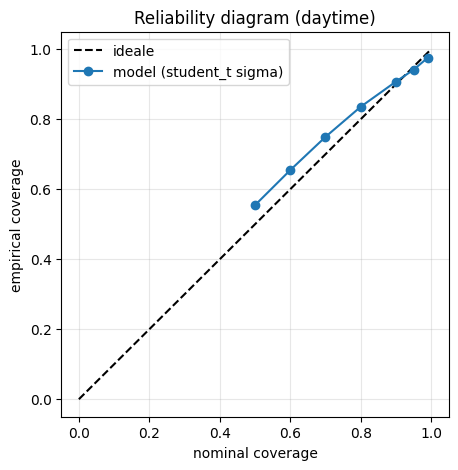

 nominal  empirical
    0.50     0.5545
    0.60     0.6546
    0.70     0.7495
    0.80     0.8356
    0.90     0.9075
    0.95     0.9413
    0.99     0.9754


In [9]:
import numpy as np, pandas as pd
from scipy.stats import norm, t as student_t
import matplotlib.pyplot as plt

# Predictions of the CURRENTLY SELECTED experiment — derive out_dir from
# BASE_CONFIG so a stale global out_dir can't point at the wrong run.
out_dir = pipe.make_out_dir(BASE_CONFIG)
PRED_CSV = str(Path(out_dir) / "predictions.csv")
print("reading:", PRED_CSV)
GAMMA, ETA = 0.95, 9.0
SOLAR_COL, SOLAR_THR = "solar_irradiance_poa_target", 10.0

# Distribution-aware quantile (lambda = paste/merge-safe, no indented block):
# t-quantile for a Student-t run, else Gaussian.
NLL_DIST = BASE_CONFIG.get("nll_dist", "gaussian")
NU = float(BASE_CONFIG.get("student_t_nu", 5.0))
qz = lambda p: float(student_t.ppf(p, NU)) if NLL_DIST == "student_t" else float(norm.ppf(p))
z = qz(0.5 + GAMMA / 2)               # 1.96 (gauss) / wider (t)

want = ["y_true", "y_pred_mean", "y_pred_std_raw", "lower_pi", "upper_pi",
        SOLAR_COL, "timestamp", "location"]
# Always load from the selected run's CSV (no stale in-memory df shortcut).
d = pd.read_csv(PRED_CSV, usecols=lambda c: c in want)

# --- daytime + finite ---
d = d[d[SOLAR_COL] > SOLAR_THR]
need = ["y_true", "y_pred_mean", "y_pred_std_raw"]
d = d[np.isfinite(d[need].to_numpy()).all(axis=1)].reset_index(drop=True)

y = d["y_true"].to_numpy(float)
mu = d["y_pred_mean"].to_numpy(float)
sig = d["y_pred_std_raw"].to_numpy(float)

rng = y.max() - y.min()                       # target_range (come report)
rmse = np.sqrt(np.mean((mu - y) ** 2))

clc = lambda picp, nmpil: nmpil * (1.0 + np.exp(-ETA * (picp - GAMMA)))  # = report CLC

def metrics(lo, hi, name):
    inside = (y >= lo) & (y <= hi)
    picp, mpiw = inside.mean(), np.mean(hi - lo)
    nmpil = mpiw / rng
    return dict(model=name, PICP=round(picp, 4), MPIW=round(mpiw, 2),
                NMPIL=round(nmpil, 4), MPIW_RMSE=round(mpiw / rmse, 3),
                CLC=round(clc(picp, nmpil), 4))

rows = []
# 1) modello, PI salvati dal runner (gia col quantile giusto: gauss o t)
rows.append(metrics(d["lower_pi"].to_numpy(float), d["upper_pi"].to_numpy(float), "model (saved PI)"))
# 2) modello, banda ricostruita dalla sua sigma col quantile della distribuzione
rows.append(metrics(mu - z * sig, mu + z * sig, f"model ({NLL_DIST} sigma)"))
# 3) baseline OMOSCHEDASTICO: sigma costante = std residui globale (gaussiano)
sig0 = np.std(mu - y)
rows.append(metrics(mu - norm.ppf(0.5 + GAMMA / 2) * sig0, mu + norm.ppf(0.5 + GAMMA / 2) * sig0, "homoschedastic"))
# 4) baseline CLIMATOLOGIA: quantili empirici di y_true per (location, mese, ora)
ts = pd.to_datetime(d["timestamp"])
d["_m"], d["_h"] = ts.dt.month, ts.dt.hour
keys = (["location"] if "location" in d.columns else []) + ["_m", "_h"]
qlo, qhi = 0.5 - GAMMA / 2, 0.5 + GAMMA / 2
g = d.groupby(keys)["y_true"]
lo_c = g.transform("quantile", qlo).to_numpy(float)     # order-safe
hi_c = g.transform("quantile", qhi).to_numpy(float)
rows.append(metrics(lo_c, hi_c, "climatology"))

res = pd.DataFrame(rows)[["model", "PICP", "MPIW", "NMPIL", "MPIW_RMSE", "CLC"]]
print(f"dist={NLL_DIST}" + (f"(nu={NU:g})" if NLL_DIST == "student_t" else "") +
      f"  target_range={rng:.2f}  RMSE={rmse:.2f}  z={z:.3f}  (gamma={GAMMA}, eta={ETA})")
print(res.to_string(index=False))

# --- reliability diagram (banda dalla sigma del modello, quantile coerente) ---
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
emp = np.array([((y >= mu - qz(.5 + L / 2) * sig) & (y <= mu + qz(.5 + L / 2) * sig)).mean() for L in levels])
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="ideale")
plt.plot(levels, emp, "o-", label=f"model ({NLL_DIST} sigma)")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability diagram (daytime)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame({"nominal": levels, "empirical": np.round(emp, 4)}).to_string(index=False))

In [ ]:
MAX_PLOT_ROWS = 500_000
figure_paths = pipe.build_posthoc_figures(out_dir, max_plot_rows=MAX_PLOT_ROWS, random_state=1)
print('figures:', list(figure_paths))

In [ ]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## 7. W&B sweep (optional)

In [ ]:
sweep_parameters = {
    'n_sde_steps': {'values': [4, 6]},
    'sigma_max': {'values': [0.3, 0.5]},
    'ood_noise_std': {'values': [0.05, 0.1]},
}
sweep_config = pipe.make_sweep_config(sweep_parameters)
sweep_config

In [ ]:
CREATE_SWEEP = False  # set True to register the sweep on W&B
if CREATE_SWEEP:
    import wandb
    sweep_id = wandb.sweep(sweep_config, project=pipe.WANDB_PROJECT, entity=pipe.WANDB_ENTITY)
    print('sweep_id:', sweep_id)
    print('wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/' + str(sweep_id))
else:
    print('Set CREATE_SWEEP=True to register. The agent runs the program in sweep_config:')
    print('  ' + pipe.SWEEP_MEMBER_SCRIPT)
    print('  wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/<sweep_id>')

## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars, figures and a compact artifact to the matching W&B run.
The sweep wrapper does this automatically per run.

In [ ]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
        )
        print(posthoc['summary'])
        print('posthoc artifact uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))